# 04_概率分布-t分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，咱们聊聊 t分布\~

首先，t 分布（Student’s t-distribution）是一种非常常见的概率分布，它是由英国统计学家 William Sealy Gosset 在 1908 年提出的。

t 分布主要用于在样本量较小的情况下进行假设检验。它在实际应用中尤其重要，因为我们往往无法获得一个完整的数据集，只能基于样本数据进行推断。

**直观的例子：**

当一个统计学家，想要研究某个城市中成年男性的平均身高。你并没有调查所有的成年男性，而是从中随机抽取了 30 名男性作为样本。你对这 30 名男性的身高做了统计，得到了他们的平均身高和样本标准差。

假设要通过这个样本来推测全体成年男性的平均身高。在理论上，若我们能够获得全体成年男性的身高数据并计算出均值，那它是一个常数。但在实际中我们只能依赖样本均值，这时候如何量化这种不确定性呢？

这就是 t 分布的作用所在。t 分布帮助我们评估样本均值与真实均值之间的差距，并在这种不确定性下做出合理的推断。

#### t分布与正态分布的关系

t 分布与正态分布非常相似，但它的尾部更厚。换句话说，t 分布比正态分布更容易产生极端值（即偏离均值的值）。

- **正态分布：** 当我们有一个足够大的样本量时，依据中心极限定理，样本均值近似服从正态分布，且其均值为总体均值，标准差为样本标准差除以样本大小的平方根。
- **t 分布：** 当样本量小于 30 或者我们无法假定总体标准差已知时，t 分布被用来描述样本均值与总体均值的差异，特别是在总体标准差未知的情况下。t 分布的形状取决于样本量（自由度），自由度越大，t 分布就越接近正态分布。

#### t 分布的特点：

- **均值为 0：** t 分布的均值通常为 0，这意味着它是对称的。
- **方差大于 1：** 与正态分布相比，t 分布的方差通常会更大，尤其是在样本量较小的时候。
- **重尾性质：** t 分布的尾部比正态分布更重，这意味着它对极端值更敏感。随着自由度的增加，t 分布会逐渐趋近于正态分布。
- **自由度：** 自由度是指在计算统计量时，独立的样本数量。自由度越大，t 分布的形状越接近标准正态分布。自由度的计算通常是样本量减去 1（n-1）。

### 公式推导

t 分布可以通过标准化的方式定义，它依赖于**样本均值与总体均值的差异**，以及样本标准差来计算。

#### 1) t统计量的计算

t 分布的核心公式是 t 统计量的计算，它是样本均值与总体均值的差异，除以样本标准差的标准误差。

具体公式：


$$
t = \frac{\bar{X} - \mu}{S / \sqrt{n}}
$$


其中：

$\bar{X}$ 是样本均值。

$\mu$ 是总体均值（通常是我们推测的值）。

$S$ 是样本的标准差。

$n$ 是样本量。

#### 2) t分布的概率密度函数（PDF）

t 分布的概率密度函数（PDF）公式如下：


$$
f(t) = \frac{\Gamma \left( \frac{v + 1}{2} \right)}{\sqrt{v \pi} \Gamma \left( \frac{v}{2} \right)} \left( 1 + \frac{t^2}{v} \right)^{-\frac{v + 1}{2}}
$$


其中：

$v$ 是自由度。

$\Gamma(x)$ 是 Gamma 函数，它是阶乘的广义形式，适用于非整数。

#### 3) t分布的累积分布函数（CDF）

t 分布的累积分布函数（CDF）给出了某个 t 值对应的累积概率，公式为：


$$
F(t; v) = P(T \leq t) = \int_{-\infty}^{t} f(x; v) dx
$$


由于该积分没有简单的解析解，通常通过数值方法（如数值积分或查表法）计算。

### Python实现：如何生成 t 分布数据

接下来，我们用 Python 来生成 t 分布数据，并可视化其形态。

我们使用 `numpy` 和 `matplotlib` 库来进行生成和绘图。

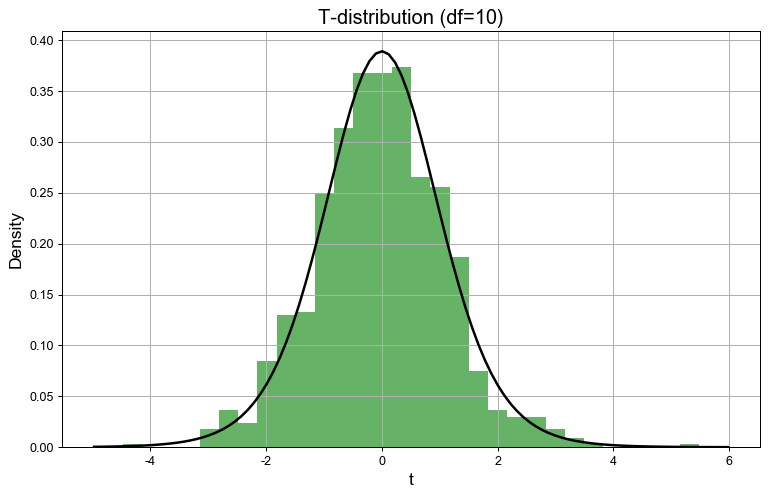

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# 设置参数
df = 10  # 自由度
size = 1000  # 生成的样本数量

# 生成 t 分布样本数据
data = t.rvs(df, size=size)

# 绘制 t 分布的直方图
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')

# 绘制 t 分布的概率密度函数（PDF）
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
pdf = t.pdf(x, df)
plt.plot(x, pdf, 'k', linewidth=2)

# 添加标题和标签
plt.title(f'T-distribution (df={df})', fontsize=16)
plt.xlabel('t', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_025.png)

- 使用 `scipy.stats.t.rvs` 来生成 t 分布的随机样本。
- `t.pdf` 用于计算 t 分布的概率密度函数（PDF）。
- 使用 `matplotlib` 绘制了直方图和理论概率密度曲线。

### t 分布在机器学习中的应用

在机器学习中，t 分布通常应用于假设检验，特别是当我们进行小样本学习时。

在回归分析、异常值检测和模型的统计推断中，t 分布可以帮助我们判断模型的可靠性。

#### 1) 应用实例：t 检验

在机器学习中，t 检验（t-test）可以用来比较两个样本的均值是否存在显著差异。这在很多任务中都很有用，比如比较两种不同算法的效果、测试不同特征对模型的影响等。

假设我们有两个模型 A 和 B，它们分别在两组不同的测试数据上进行训练和评估。我们想知道这两个模型的平均性能是否显著不同。我们可以使用 t 检验来计算它们的均值差异是否显著。

#### 2) Python 实现：t 检验

In [3]:
from scipy import stats

# 假设模型 A 和 B 的评估得分
model_a_scores = np.array([88, 90, 85, 87, 92, 91, 89, 90, 86, 93])
model_b_scores = np.array([80, 82, 79, 81, 83, 78, 77, 80, 79, 82])

# 进行 t 检验
t_stat, p_value = stats.ttest_ind(model_a_scores, model_b_scores)

# 输出结果
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# 判断是否拒绝零假设
if p_value < 0.05:
    print("拒绝零假设：模型 A 和模型 B 的性能存在显著差异。")
else:
    print("无法拒绝零假设：模型 A 和模型 B 的性能没有显著差异。")

T-statistic: 8.816
P-value: 0.000
拒绝零假设：模型 A 和模型 B 的性能存在显著差异。


- `ttest_ind` 是用于两组独立样本之间的 t 检验函数。它返回 t 统计量和 p 值。
- p 值小于 0.05 时，我们可以拒绝零假设，认为两个模型之间存在显著差异。

### 最后

t 分布在小样本推断中起到了至关重要的作用。整个内容咱们通过例子、公式推导、Python 实现和机器学习应用的介绍，希望帮助到大家全面了解了 t 分布的定义、性质、计算方式以及其在实际中的应用。